Импорты и пути к файлам

In [2]:
import os, glob, json, warnings
import numpy as np
import pandas as pd
import librosa
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from collections import Counter

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

warnings.filterwarnings('ignore')


AUDIO_ROOT = r"C:\mtg_data"
REPO_ROOT  = r"C:\mtg-jamendo-dataset"
SPLIT_DIR  = os.path.join(REPO_ROOT, "data", "splits", "split-0")
SAVE_DIR   = r"C:\music_ai_results"
os.makedirs(SAVE_DIR, exist_ok=True)

SAMPLE_RATE = 16000
DURATION    = 30

C:\anaconda\envs\music_ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Сканирование и парсинг сплитов

In [3]:
audio_files = glob.glob(os.path.join(AUDIO_ROOT, "*", "*.mp3"))
track_to_path = {}
for f in audio_files:
    file_id = os.path.splitext(os.path.basename(f))[0]
    track_id = f"track_{int(file_id):07d}"
    track_to_path[track_id] = f
print(f"Найдено аудио: {len(track_to_path)}")

# Парсим сплиты 
def parse_mood_tsv_clean(tsv_path):
    ids, tags_raw = [], []
    with open(tsv_path, 'r', encoding='utf-8') as f:
        f.readline()
        for line in f:
            parts = line.strip().split('\t', maxsplit=5)
            if len(parts) < 6: continue
            tid = parts[0]
            clean = parts[5].replace('mood/theme---', ' ').replace('mood/theme', ' ')
            tags_list = [t.strip() for t in clean.split('\t') if t.strip()]
            ids.append(tid)
            tags_raw.append(tags_list)
    return ids, tags_raw

train_ids, train_tags = parse_mood_tsv_clean(os.path.join(SPLIT_DIR, "autotagging_moodtheme-train.tsv"))
val_ids,   val_tags   = parse_mood_tsv_clean(os.path.join(SPLIT_DIR, "autotagging_moodtheme-validation.tsv"))
test_ids,  test_tags  = parse_mood_tsv_clean(os.path.join(SPLIT_DIR, "autotagging_moodtheme-test.tsv"))

Найдено аудио: 18486


Маппинг

In [4]:
TAG_GROUP = {
    # 1. Happy / Upbeat
    'happy':      'happy_upbeat',
    'upbeat':     'happy_upbeat',
    'fun':        'happy_upbeat',
    'energetic':  'happy_upbeat',
    'party':      'happy_upbeat',
    'groovy':     'happy_upbeat',
    'fast':       'happy_upbeat',
    'positive':   'happy_upbeat',
    
    # 2. Sad / Melancholic
    'sad':          'sad_melancholic',
    'melancholic': 'sad_melancholic',
    'emotional':   'sad_melancholic',
    'dramatic':    'sad_melancholic',
    
    # 3. Calm / Relaxing
    'calm':        'calm_relaxing',
    'relaxing':    'calm_relaxing',
    'soft':        'calm_relaxing',
    'mellow':      'calm_relaxing',
    'meditative':  'calm_relaxing',
    'background':  'calm_relaxing',
    'ambiental':   'calm_relaxing',
    'nature':      'calm_relaxing',
    'soundscape':  'calm_relaxing',
    'space':       'calm_relaxing',
    'slow':        'calm_relaxing',
    'dream':       'calm_relaxing',
    
    # 4. Epic / Powerful
    'epic':        'epic_powerful',
    'powerful':    'epic_powerful',
    'motivational':'epic_powerful',
    'inspiring':   'epic_powerful',
    'adventure':   'epic_powerful',
    'trailer':     'epic_powerful',
    
    # 5. Dark / Heavy
    'dark':   'dark_heavy',
    'horror': 'dark_heavy',
    'heavy':  'dark_heavy',
    'deep':   'dark_heavy',
    
    # 6. Love / Romantic
    'love':     'love_romantic',
    'romantic': 'love_romantic',
    'sexy':     'love_romantic',
    
    # 7. Cinematic
    'film':        'cinematic',
    'movie':       'cinematic',
    'documentary': 'cinematic',
    'drama':       'cinematic',
}

ALL_GROUPS = sorted(list(set(TAG_GROUP.values())))
GROUP_TO_IDX = {g: i for i, g in enumerate(ALL_GROUPS)}
print("Итоговые настроения:", ALL_GROUPS)

Итоговые настроения: ['calm_relaxing', 'cinematic', 'dark_heavy', 'epic_powerful', 'happy_upbeat', 'love_romantic', 'sad_melancholic']


In [5]:
def tags_to_group_multihot(tags_list):
    vec = np.zeros(len(ALL_GROUPS), dtype=np.float32)
    for t in tags_list:
        group = TAG_GROUP.get(t)
        if group is not None:
            vec[GROUP_TO_IDX[group]] = 1.0
    return vec

# Применяем ко всем трём сплитам
y_train_full = np.array([tags_to_group_multihot(lst) for lst in tqdm(train_tags, desc="Train labels")])
y_val_full   = np.array([tags_to_group_multihot(lst) for lst in tqdm(val_tags, desc="Val labels")])
y_test_full  = np.array([tags_to_group_multihot(lst) for lst in tqdm(test_tags, desc="Test labels")])
print("Формы меток:", y_train_full.shape, y_val_full.shape, y_test_full.shape)

Test labels: 100%|█████████████████████████████████████████████████████████████| 4231/4231 [00:00<00:00, 846261.34it/s]

Формы меток: (9949, 7) (3802, 7) (4231, 7)


Фильтрация неиспользуемых меток

In [6]:
available = set(track_to_path.keys())

def filter_existing(ids, labels):
    f_ids, f_labs = [], []
    for tid, lab in zip(ids, labels):
        if tid in available:
            f_ids.append(tid)
            f_labs.append(lab)
    return f_ids, np.array(f_labs, dtype=np.float32)

train_ids_ex, y_train_ex = filter_existing(train_ids, y_train_full)
val_ids_ex,   y_val_ex   = filter_existing(val_ids,   y_val_full)
test_ids_ex,  y_test_ex  = filter_existing(test_ids,  y_test_full)
print(f"После аудио-фильтрации: train={len(train_ids_ex)}, val={len(val_ids_ex)}, test={len(test_ids_ex)}")

После аудио-фильтрации: train=9949, val=3802, test=4231


Деление на 80 10 10

In [7]:
# Собираем в один пул
all_ids = train_ids_ex + val_ids_ex + test_ids_ex
all_labels = np.vstack([y_train_ex, y_val_ex, y_test_ex])

# Удаляем треки, у которых нет ни одной метки
has_label = all_labels.sum(axis=1) > 0
all_ids = [all_ids[i] for i, keep in enumerate(has_label) if keep]
all_labels = all_labels[has_label]
print(f"После удаления пустых: {len(all_ids)} треков")

# 80 10 10
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(msss.split(all_ids, all_labels))

msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(msss2.split(np.array(all_ids)[temp_idx], all_labels[temp_idx]))

train_ids_new = np.array(all_ids)[train_idx]
val_ids_new   = np.array(all_ids)[temp_idx][val_idx]
test_ids_new  = np.array(all_ids)[temp_idx][test_idx]

y_train = all_labels[train_idx]
y_val   = all_labels[temp_idx][val_idx]
y_test  = all_labels[temp_idx][test_idx]

print(f"Train: {len(train_ids_new)}, Val: {len(val_ids_new)}, Test: {len(test_ids_new)}")
print(f"Среднее число меток: train={y_train.sum(axis=1).mean():.2f}, val={y_val.sum(axis=1).mean():.2f}, test={y_test.sum(axis=1).mean():.2f}")

# Частоты групп
for i, group in enumerate(ALL_GROUPS):
    print(f"  {group}: train={y_train[:,i].sum()}, val={y_val[:,i].sum()}, test={y_test[:,i].sum()}")

После удаления пустых: 15273 треков
Train: 12236, Val: 1538, Test: 1499
Среднее число меток: train=1.33, val=1.32, test=1.36
  calm_relaxing: train=4018.0, val=502.0, test=503.0
  cinematic: train=2070.0, val=259.0, test=259.0
  dark_heavy: train=1570.0, val=196.0, test=197.0
  epic_powerful: train=2198.0, val=274.0, test=275.0
  happy_upbeat: train=3169.0, val=396.0, test=396.0
  love_romantic: train=1214.0, val=151.0, test=152.0
  sad_melancholic: train=2005.0, val=250.0, test=251.0


Загрузка VGGIsh

In [10]:
VGGISH_DIR = os.path.join(SAVE_DIR, "vggish_model")
os.makedirs(VGGISH_DIR, exist_ok=True)

archive_path = tf.keras.utils.get_file(
    fname="vggish.tar.gz",
    origin="https://tfhub.dev/google/vggish/1?tf-hub-format=compressed",
    cache_dir=VGGISH_DIR,
    cache_subdir=""
)
if not os.path.exists(os.path.join(VGGISH_DIR, "saved_model.pb")):
    with tarfile.open(archive_path, 'r:gz') as tar:
        tar.extractall(VGGISH_DIR)
    os.remove(archive_path)
    print("VGGish распакован")

vggish_model = tf.saved_model.load(VGGISH_DIR)
print("VGGish загружен")

VGGish загружен


Форма мел‑спектрограммы: (1300, 128, 1)
Форма усреднённой мел‑спектрограммы: (128,)
Форма VGGish‑эмбеддинга: (128,)


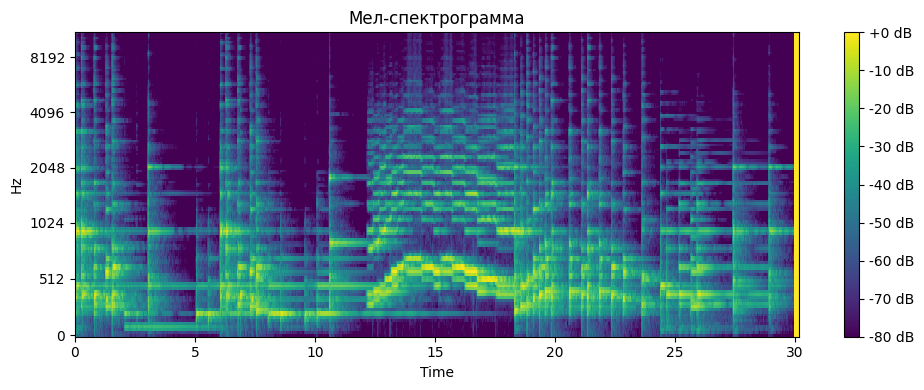

In [14]:
def extract_melspec(audio_path, sr=22050, duration=30, n_mels=128, target_time=1300):
    y, _ = librosa.load(audio_path, sr=sr, mono=True, duration=duration)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512,
                                         n_mels=n_mels, fmin=20, fmax=8000)
    mel_db = librosa.power_to_db(mel, ref=np.max)          # УЖЕ в дБ
    if mel_db.shape[1] < target_time:
        pad = target_time - mel_db.shape[1]
        mel_db = np.pad(mel_db, ((0,0),(0,pad)), mode='constant')
    else:
        mel_db = mel_db[:, :target_time]
    return mel_db.T[..., np.newaxis]  # (time, n_mels, 1)

def extract_avg_melspec(audio_path):
    mel = extract_melspec(audio_path)   # (time, n_mels, 1)
    return mel.mean(axis=(0, 2))        # (n_mels,)

def extract_vggish(audio_path):
    y, _ = librosa.load(audio_path, sr=16000, mono=True, duration=DURATION)
    emb = vggish_model(y)
    return emb.numpy().mean(axis=0)

example_track = list(track_to_path.values())[0]

# 1. Мел‑спектрограмма
mel_spec = extract_melspec(example_track)   # (time, n_mels, 1) в дБ
print("Форма мел‑спектрограммы:", mel_spec.shape)

# 2. Усреднённая мел‑спектрограмма
avg_mel = extract_avg_melspec(example_track)
print("Форма усреднённой мел‑спектрограммы:", avg_mel.shape)

# 3. VGGish‑эмбеддинг
vgg_emb = extract_vggish(example_track)
print("Форма VGGish‑эмбеддинга:", vgg_emb.shape)

# 4. Правильная визуализация
plt.figure(figsize=(10, 4))
# mel_spec имеет форму (time, n_mels, 1) транспонируем в (n_mels, time)
img = mel_spec[..., 0].T   # (n_mels, time), уже в дБ
librosa.display.specshow(img, sr=22050, hop_length=512, x_axis='time', y_axis='mel', cmap='viridis')
plt.colorbar(format='%+2.0f dB')
plt.title('Мел‑спектрограмма')
plt.tight_layout()
plt.show()

Извлечение признаков

In [15]:
# Baseline
X_train_lr = np.array([extract_avg_melspec(track_to_path[tid]) for tid in tqdm(train_ids_new, desc="LR Train")])
X_val_lr   = np.array([extract_avg_melspec(track_to_path[tid]) for tid in tqdm(val_ids_new,   desc="LR Val")])
X_test_lr  = np.array([extract_avg_melspec(track_to_path[tid]) for tid in tqdm(test_ids_new,  desc="LR Test")])

scaler = StandardScaler()
X_train_lr = scaler.fit_transform(X_train_lr)
X_val_lr   = scaler.transform(X_val_lr)
X_test_lr  = scaler.transform(X_test_lr)

# VGGish
X_train_vgg = np.array([extract_vggish(track_to_path[tid]) for tid in tqdm(train_ids_new, desc="VGGish Train")])
X_val_vgg   = np.array([extract_vggish(track_to_path[tid]) for tid in tqdm(val_ids_new,   desc="VGGish Val")])
X_test_vgg  = np.array([extract_vggish(track_to_path[tid]) for tid in tqdm(test_ids_new,  desc="VGGish Test")])

# CNN 
X_train_mel = np.array([extract_melspec(track_to_path[tid]) for tid in tqdm(train_ids_new, desc="CNN Train")])
X_val_mel   = np.array([extract_melspec(track_to_path[tid]) for tid in tqdm(val_ids_new,   desc="CNN Val")])
X_test_mel  = np.array([extract_melspec(track_to_path[tid]) for tid in tqdm(test_ids_new,  desc="CNN Test")])
print("Формы признаков:")
print("LR:", X_train_lr.shape, "VGGish:", X_train_vgg.shape, "CNN:", X_train_mel.shape)

CNN Test: 100%|████████████████████████████████████████████████████████████████████| 1499/1499 [01:37<00:00, 15.36it/s]


Формы признаков:
LR: (12236, 128) VGGish: (12236, 128) CNN: (12236, 1300, 128, 1)


логистическая регрессия

In [22]:
lr_model = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr_model.fit(X_train_lr, y_train)

# Подбор порога на валидации
val_probs_lr = lr_model.predict_proba(X_val_lr)
best_t_lr, best_f1_lr = 0.5, 0.0
for t in np.arange(0.05, 0.95, 0.05):
    preds = (val_probs_lr > t).astype(int)
    f1 = f1_score(y_val, preds, average='micro', zero_division=0)
    if f1 > best_f1_lr:
        best_f1_lr, best_t_lr = f1, t

test_probs_lr = lr_model.predict_proba(X_test_lr)
test_preds_lr = (test_probs_lr > best_t_lr).astype(int)

print(f"Baseline LR: порог {best_t_lr:.2f}, micro‑F1 {best_f1_lr:.4f}")
print(classification_report(y_test, test_preds_lr, target_names=ALL_GROUPS, zero_division=0))

Baseline LR: порог 0.25, micro‑F1 0.4179
                 precision    recall  f1-score   support

  calm_relaxing       0.40      0.81      0.54       503
      cinematic       0.28      0.31      0.29       259
     dark_heavy       0.31      0.22      0.26       197
  epic_powerful       0.31      0.35      0.33       275
   happy_upbeat       0.44      0.70      0.54       396
  love_romantic       0.26      0.10      0.14       152
sad_melancholic       0.33      0.33      0.33       251

      micro avg       0.37      0.49      0.42      2033
      macro avg       0.33      0.40      0.35      2033
   weighted avg       0.35      0.49      0.40      2033
    samples avg       0.40      0.52      0.42      2033



In [24]:
def any_match(y_true, y_pred):
    return ((y_true.astype(int) & y_pred.astype(int)).sum(axis=1) > 0).mean() 

def exact_match(y_true, y_pred):
    return (y_true.astype(int) == y_pred.astype(int)).all(axis=1).mean()

def avg_hits(y_true, y_pred):
    return (y_true.astype(int) & y_pred.astype(int)).sum(axis=1).mean()

print("Logistic Regression")
print(f"Лучший порог (валидация): {best_t_lr:.2f}, микро‑F1: {best_f1_lr:.4f}")
print(classification_report(y_test, test_preds_lr, target_names=ALL_GROUPS, zero_division=0))

any_lr = any_match(y_test, test_preds_lr)
exact_lr = exact_match(y_test, test_preds_lr)
hits_lr = avg_hits(y_test, test_preds_lr)
print(f"Хотя бы одно угадано: {any_lr*100:.1f}%")
print(f"Все угаданы точно:    {exact_lr*100:.1f}%")
print(f"Среднее число угаданных: {hits_lr:.2f} из {y_test.sum(axis=1).mean():.2f}")

Logistic Regression
Лучший порог (валидация): 0.25, микро‑F1: 0.4179
                 precision    recall  f1-score   support

  calm_relaxing       0.40      0.81      0.54       503
      cinematic       0.28      0.31      0.29       259
     dark_heavy       0.31      0.22      0.26       197
  epic_powerful       0.31      0.35      0.33       275
   happy_upbeat       0.44      0.70      0.54       396
  love_romantic       0.26      0.10      0.14       152
sad_melancholic       0.33      0.33      0.33       251

      micro avg       0.37      0.49      0.42      2033
      macro avg       0.33      0.40      0.35      2033
   weighted avg       0.35      0.49      0.40      2033
    samples avg       0.40      0.52      0.42      2033

Хотя бы одно угадано: 61.3%
Все угаданы точно:    14.1%
Среднее число угаданных: 0.67 из 1.36


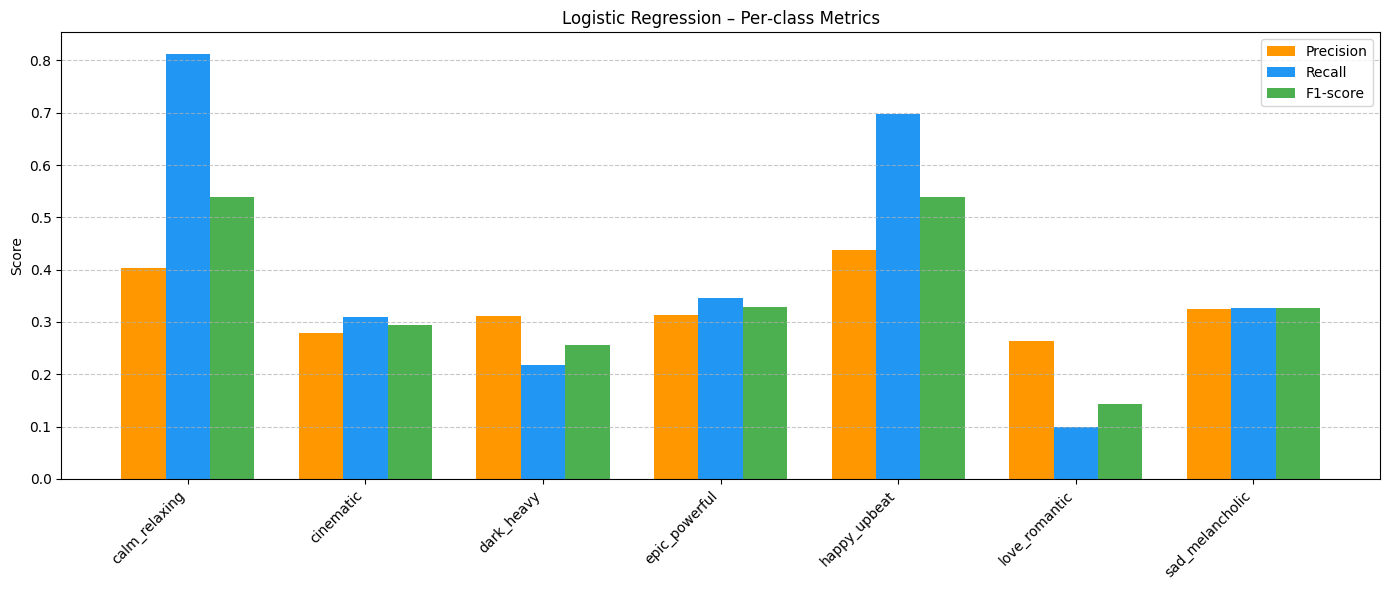

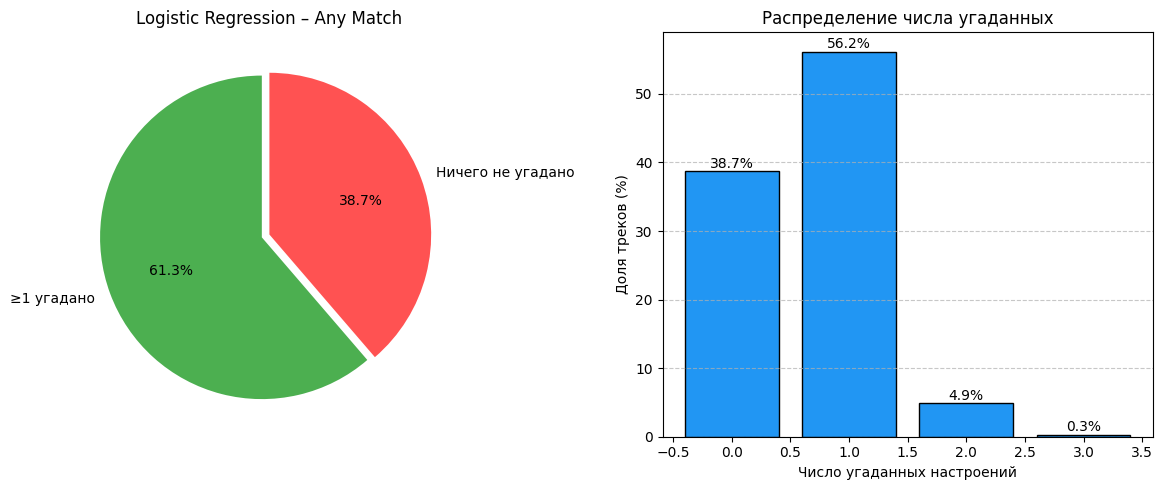

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from collections import Counter

# Метрики по классам
report = classification_report(y_test, test_preds_lr, target_names=ALL_GROUPS, output_dict=True, zero_division=0)
metrics_per_class = {label: {k: report[label][k] for k in ('precision', 'recall', 'f1-score')}
                     for label in ALL_GROUPS if label in report}

# Bar chart
x = np.arange(len(ALL_GROUPS))
width = 0.25
precisions = [metrics_per_class[g]['precision'] for g in ALL_GROUPS]
recalls    = [metrics_per_class[g]['recall'] for g in ALL_GROUPS]
f1s        = [metrics_per_class[g]['f1-score'] for g in ALL_GROUPS]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, precisions, width, label='Precision', color='#FF9800')
ax.bar(x,        recalls,    width, label='Recall',    color='#2196F3')
ax.bar(x + width, f1s,       width, label='F1-score',  color='#4CAF50')
ax.set_xticks(x)
ax.set_xticklabels(ALL_GROUPS, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Logistic Regression – Per‑class Metrics')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'lr_per_class_metrics.png'), dpi=150)
plt.show()

# Графики
any_match = ((y_test.astype(int) & test_preds_lr.astype(int)).sum(axis=1) > 0).mean()
exact_match = (y_test.astype(int) == test_preds_lr.astype(int)).all(axis=1).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Круговая диаграмма
labels_pie = ['≥1 угадано', 'Ничего не угадано']
sizes = [any_match*100, 100-any_match*100]
colors = ['#4CAF50', '#FF5252']
ax1.pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0))
ax1.set_title('Logistic Regression – Any Match')

# Распределение числа угаданных меток
hits = (y_test.astype(int) & test_preds_lr.astype(int)).sum(axis=1)
cnt = Counter(hits)
total = len(hits)
bars = ax2.bar([int(k) for k in sorted(cnt.keys())], [cnt[k]/total*100 for k in sorted(cnt.keys())],
               color='#2196F3', edgecolor='black')
ax2.set_xlabel('Число угаданных настроений')
ax2.set_ylabel('Доля треков (%)')
ax2.set_title('Распределение числа угаданных')
for bar, (k, _) in zip(bars, sorted(cnt.items())):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{cnt[k]/total*100:.1f}%', ha='center')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'lr_human_metrics.png'), dpi=150)
plt.show()

Vggish

In [26]:
model_vgg = models.Sequential([
    layers.Input(shape=(128,)),
    layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(len(ALL_GROUPS), activation='sigmoid')
])

model_vgg.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

callbacks_vgg = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(SAVE_DIR, 'best_vgg_f.keras'), monitor='val_loss', save_best_only=True)
]

history_vgg = model_vgg.fit(
    X_train_vgg, y_train,
    validation_data=(X_val_vgg, y_val),
    epochs=50, batch_size=128,
    callbacks=callbacks_vgg, verbose=1
)

# Оценка
val_probs_vgg = model_vgg.predict(X_val_vgg)
best_t_vgg, best_f1_vgg = 0.5, 0.0
for t in np.arange(0.05, 0.95, 0.05):
    preds = (val_probs_vgg > t).astype(int)
    f1 = f1_score(y_val, preds, average='micro', zero_division=0)
    if f1 > best_f1_vgg:
        best_f1_vgg, best_t_vgg = f1, t

test_probs_vgg = model_vgg.predict(X_test_vgg)
test_preds_vgg = (test_probs_vgg > best_t_vgg).astype(int)

print(f"VGGish: порог {best_t_vgg:.2f}, micro‑F1 {best_f1_vgg:.4f}")
print(classification_report(y_test, test_preds_vgg, target_names=ALL_GROUPS, zero_division=0))

Epoch 1/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - binary_accuracy: 0.7956 - loss: 0.6969 - val_binary_accuracy: 0.8218 - val_loss: 0.5533
Epoch 2/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8148 - loss: 0.5330 - val_binary_accuracy: 0.8246 - val_loss: 0.4808
Epoch 3/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8177 - loss: 0.4830 - val_binary_accuracy: 0.8246 - val_loss: 0.4539
Epoch 4/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8193 - loss: 0.4609 - val_binary_accuracy: 0.8257 - val_loss: 0.4387
Epoch 5/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8193 - loss: 0.4503 - val_binary_accuracy: 0.8255 - val_loss: 0.4303
Epoch 6/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8203 - loss: 0.4441 - val_binary_accuracy: 0.8245 - val_loss: 0.4276
Epoch 7/50
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - binary_accuracy: 0.8206 - loss: 0.4403 - val_binary_accuracy: 0.8261 - val_loss: 0.4254
Epoch 8/50
96/96 ━━

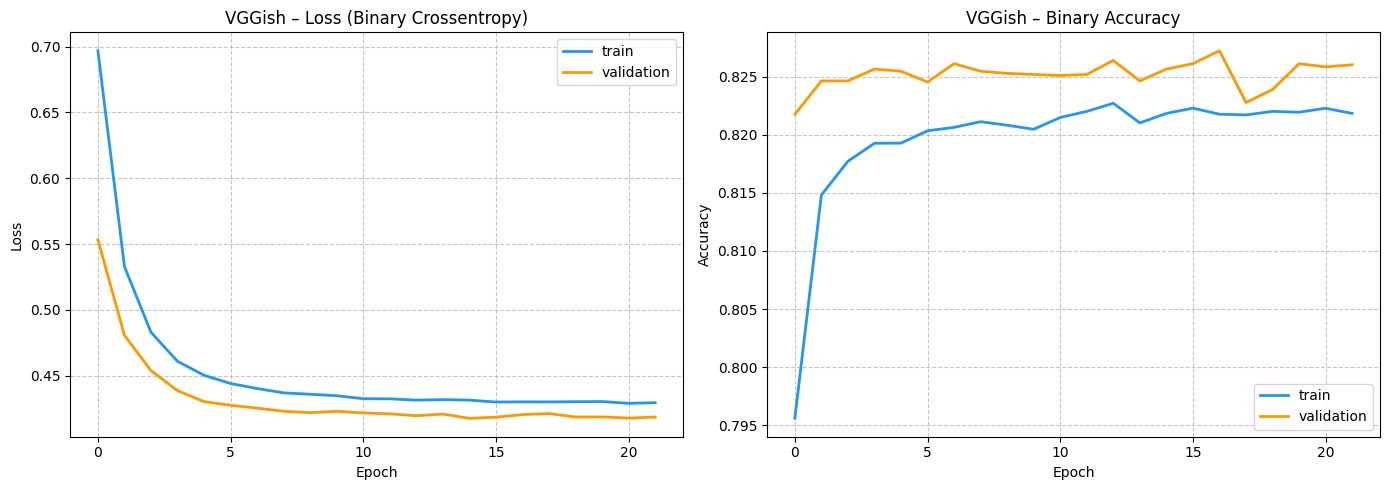

In [27]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history_vgg.history['loss'], label='train', linewidth=2, color='#2196F3')
ax1.plot(history_vgg.history['val_loss'], label='validation', linewidth=2, color='#FF9800')
ax1.set_title('VGGish – Loss (Binary Crossentropy)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Accuracy (binary)
ax2.plot(history_vgg.history['binary_accuracy'], label='train', linewidth=2, color='#2196F3')
ax2.plot(history_vgg.history['val_binary_accuracy'], label='validation', linewidth=2, color='#FF9800')
ax2.set_title('VGGish – Binary Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'vggish_learning_curves.png'), dpi=150)
plt.show()

                 precision    recall  f1-score   support

  calm_relaxing       0.45      0.85      0.59       503
      cinematic       0.39      0.46      0.42       259
     dark_heavy       0.39      0.31      0.35       197
  epic_powerful       0.47      0.36      0.40       275
   happy_upbeat       0.51      0.78      0.62       396
  love_romantic       0.38      0.08      0.13       152
sad_melancholic       0.38      0.37      0.37       251

      micro avg       0.45      0.55      0.49      2033
      macro avg       0.42      0.46      0.41      2033
   weighted avg       0.44      0.55      0.46      2033
    samples avg       0.49      0.58      0.50      2033



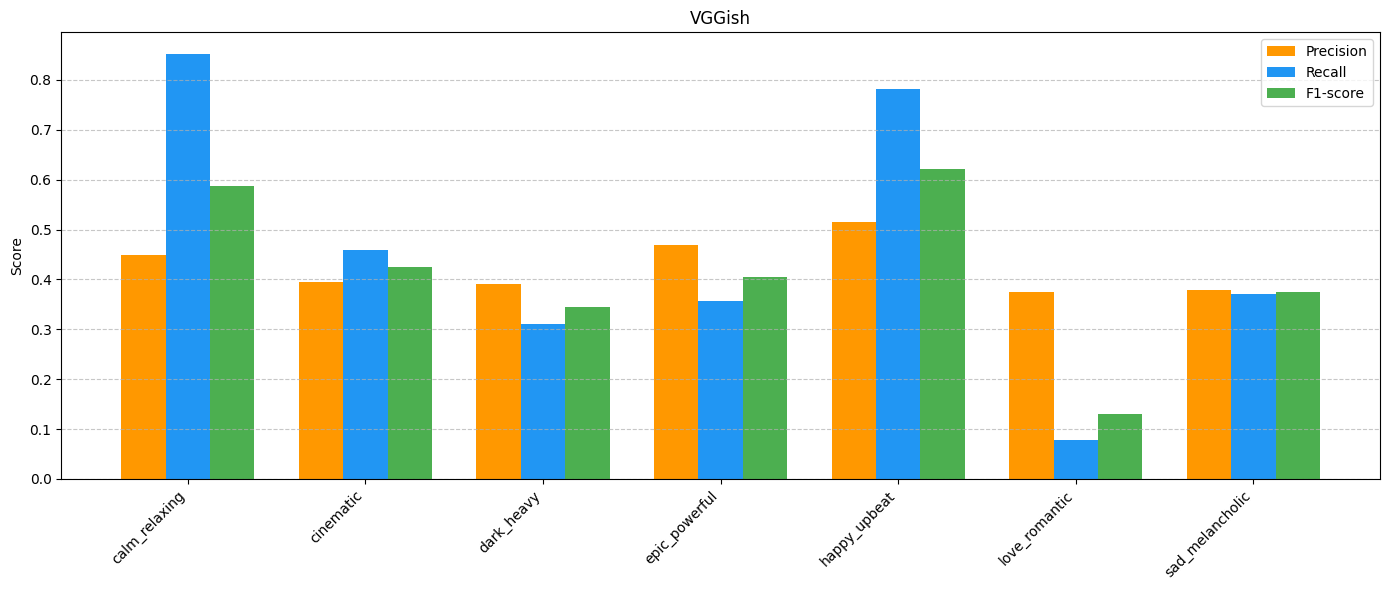

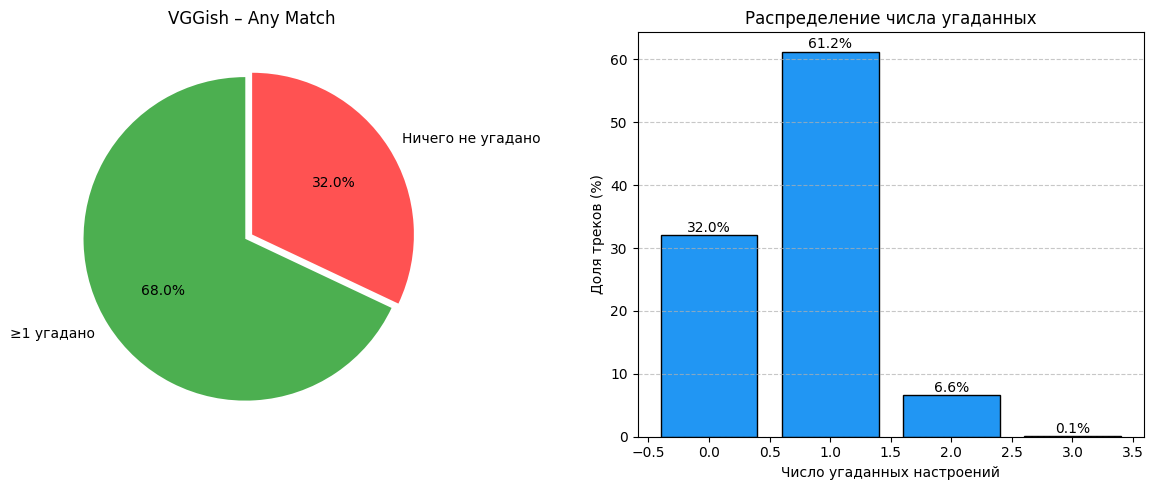

In [28]:
# 1. Поклассовые метрики
print(classification_report(y_test, test_preds_vgg, target_names=ALL_GROUPS, zero_division=0))

report = classification_report(y_test, test_preds_vgg, target_names=ALL_GROUPS, output_dict=True, zero_division=0)
metrics_per_class = {label: {k: report[label][k] for k in ('precision', 'recall', 'f1-score')}
                     for label in ALL_GROUPS if label in report}
x = np.arange(len(ALL_GROUPS))
width = 0.25
precisions = [metrics_per_class[g]['precision'] for g in ALL_GROUPS]
recalls    = [metrics_per_class[g]['recall'] for g in ALL_GROUPS]
f1s        = [metrics_per_class[g]['f1-score'] for g in ALL_GROUPS]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, precisions, width, label='Precision', color='#FF9800')
ax.bar(x,        recalls,    width, label='Recall',    color='#2196F3')
ax.bar(x + width, f1s,       width, label='F1-score',  color='#4CAF50')
ax.set_xticks(x)
ax.set_xticklabels(ALL_GROUPS, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('VGGish')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'vggish_per_class_metrics.png'), dpi=150)
plt.show()

#Графики
any_match = ((y_test.astype(int) & test_preds_vgg.astype(int)).sum(axis=1) > 0).mean()
exact_match = (y_test.astype(int) == test_preds_vgg.astype(int)).all(axis=1).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
labels_pie = ['≥1 угадано', 'Ничего не угадано']
sizes = [any_match*100, 100-any_match*100]
colors = ['#4CAF50', '#FF5252']
ax1.pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0))
ax1.set_title('VGGish – Any Match')

hits = (y_test.astype(int) & test_preds_vgg.astype(int)).sum(axis=1)
cnt = Counter(hits)
total = len(hits)
bars = ax2.bar([int(k) for k in sorted(cnt.keys())], [cnt[k]/total*100 for k in sorted(cnt.keys())],
               color='#2196F3', edgecolor='black')
ax2.set_xlabel('Число угаданных настроений')
ax2.set_ylabel('Доля треков (%)')
ax2.set_title('Распределение числа угаданных')
for bar, (k, _) in zip(bars, sorted(cnt.items())):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{cnt[k]/total*100:.1f}%', ha='center')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'vggish_human_metrics.png'), dpi=150)
plt.show()

CNN

In [30]:
def build_simple_cnn(input_shape, num_tags):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(128, (3,3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu', kernel_regularizer=l2(0.0005))(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_tags, activation='sigmoid')(x)
    return models.Model(inp, out)

model_cnn = build_simple_cnn(X_train_mel.shape[1:], len(ALL_GROUPS))
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['binary_accuracy'])

callbacks_cnn = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ModelCheckpoint(os.path.join(SAVE_DIR, 'best_cnn.keras'), monitor='val_loss', save_best_only=True)
]

history_cnn = model_cnn.fit(
    X_train_mel, y_train,
    validation_data=(X_val_mel, y_val),
    epochs=50, batch_size=32,
    callbacks=callbacks_cnn, verbose=1
)

# Оценка
val_probs_cnn = model_cnn.predict(X_val_mel)
best_t_cnn, best_f1_cnn = 0.5, 0.0
for t in np.arange(0.05, 0.95, 0.05):
    preds = (val_probs_cnn > t).astype(int)
    f1 = f1_score(y_val, preds, average='micro', zero_division=0)
    if f1 > best_f1_cnn:
        best_f1_cnn, best_t_cnn = f1, t

test_probs_cnn = model_cnn.predict(X_test_mel)
test_preds_cnn = (test_probs_cnn > best_t_cnn).astype(int)

print(f"Своя CNN: порог {best_t_cnn:.2f}, micro‑F1 {best_f1_cnn:.4f}")
print(classification_report(y_test, test_preds_cnn, target_names=ALL_GROUPS, zero_division=0))

Epoch 1/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 1025s 3s/step - binary_accuracy: 0.8045 - loss: 0.5140 - val_binary_accuracy: 0.8133 - val_loss: 0.4789
Epoch 2/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 989s 3s/step - binary_accuracy: 0.8132 - loss: 0.4663 - val_binary_accuracy: 0.8132 - val_loss: 0.4763
Epoch 3/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 972s 3s/step - binary_accuracy: 0.8155 - loss: 0.4499 - val_binary_accuracy: 0.8163 - val_loss: 0.4622
Epoch 4/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 972s 3s/step - binary_accuracy: 0.8151 - loss: 0.4420 - val_binary_accuracy: 0.8175 - val_loss: 0.4447
Epoch 5/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 970s 3s/step - binary_accuracy: 0.8154 - loss: 0.4381 - val_binary_accuracy: 0.8143 - val_loss: 0.4386
Epoch 6/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 971s 3s/step - binary_accuracy: 0.8160 - loss: 0.4349 - val_binary_accuracy: 0.8086 - val_loss: 0.5439
Epoch 7/50
383/383 ━━━━━━━━━━━━━━━━━━━━ 969s 3s/step - binary_accuracy: 0.8174 - loss: 0.4313 - val_binary_accuracy: 0.8139 - val_loss: 0.499

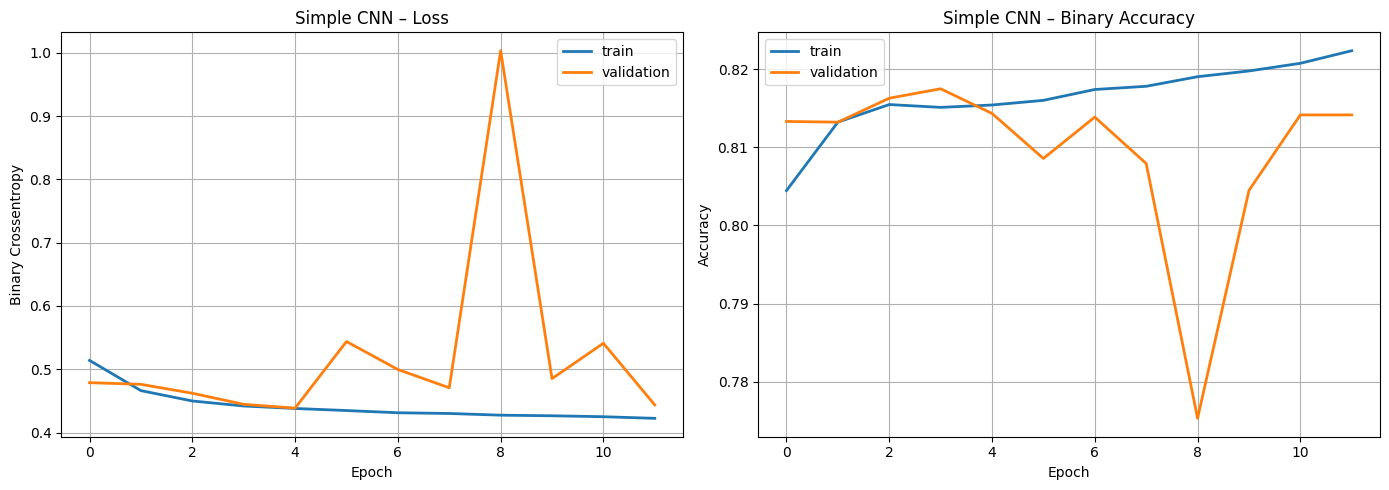

In [31]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(history_cnn.history['loss'], label='train', linewidth=2)
ax1.plot(history_cnn.history['val_loss'], label='validation', linewidth=2)
ax1.set_title('Simple CNN – Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Binary Crossentropy')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(history_cnn.history['binary_accuracy'], label='train', linewidth=2)
ax2.plot(history_cnn.history['val_binary_accuracy'], label='validation', linewidth=2)
ax2.set_title('Simple CNN – Binary Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cnn_learning_curves.png'), dpi=150)
plt.show()

                 precision    recall  f1-score   support

  calm_relaxing       0.46      0.69      0.55       503
      cinematic       0.27      0.59      0.37       259
     dark_heavy       0.50      0.08      0.13       197
  epic_powerful       0.27      0.69      0.38       275
   happy_upbeat       0.43      0.82      0.57       396
  love_romantic       1.00      0.01      0.01       152
sad_melancholic       0.31      0.23      0.26       251

      micro avg       0.36      0.54      0.43      2033
      macro avg       0.46      0.44      0.33      2033
   weighted avg       0.43      0.54      0.39      2033
    samples avg       0.39      0.56      0.43      2033



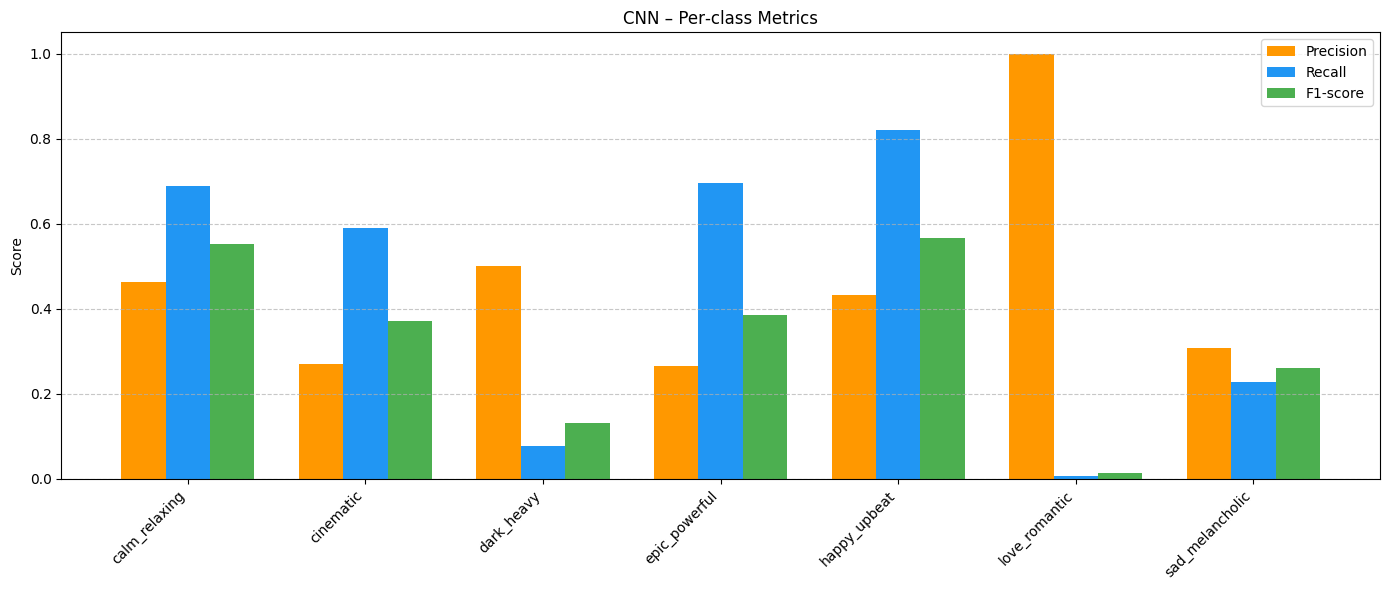

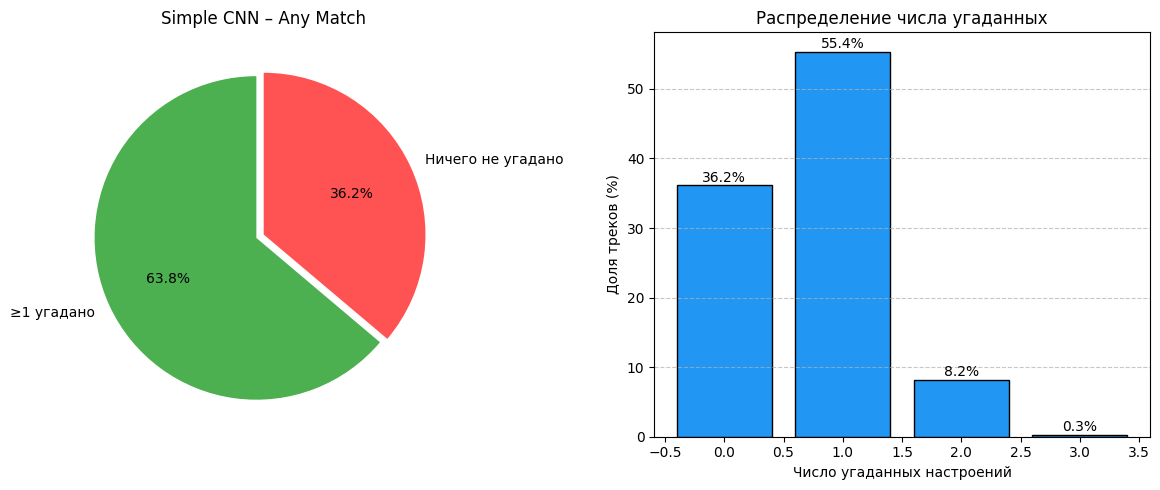

In [32]:
print(classification_report(y_test, test_preds_cnn, target_names=ALL_GROUPS, zero_division=0))

report = classification_report(y_test, test_preds_cnn, target_names=ALL_GROUPS, output_dict=True, zero_division=0)
metrics_per_class = {label: {k: report[label][k] for k in ('precision', 'recall', 'f1-score')}
                     for label in ALL_GROUPS if label in report}
x = np.arange(len(ALL_GROUPS))
width = 0.25
precisions = [metrics_per_class[g]['precision'] for g in ALL_GROUPS]
recalls    = [metrics_per_class[g]['recall'] for g in ALL_GROUPS]
f1s        = [metrics_per_class[g]['f1-score'] for g in ALL_GROUPS]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, precisions, width, label='Precision', color='#FF9800')
ax.bar(x,        recalls,    width, label='Recall',    color='#2196F3')
ax.bar(x + width, f1s,       width, label='F1-score',  color='#4CAF50')
ax.set_xticks(x)
ax.set_xticklabels(ALL_GROUPS, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('CNN – Per‑class Metrics')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cnn_per_class_metrics.png'), dpi=150)
plt.show()

any_match = ((y_test.astype(int) & test_preds_cnn.astype(int)).sum(axis=1) > 0).mean()
exact_match = (y_test.astype(int) == test_preds_cnn.astype(int)).all(axis=1).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
labels_pie = ['≥1 угадано', 'Ничего не угадано']
sizes = [any_match*100, 100-any_match*100]
colors = ['#4CAF50', '#FF5252']
ax1.pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0))
ax1.set_title('Simple CNN – Any Match')

hits = (y_test.astype(int) & test_preds_cnn.astype(int)).sum(axis=1)
cnt = Counter(hits)
total = len(hits)
bars = ax2.bar([int(k) for k in sorted(cnt.keys())], [cnt[k]/total*100 for k in sorted(cnt.keys())],
               color='#2196F3', edgecolor='black')
ax2.set_xlabel('Число угаданных настроений')
ax2.set_ylabel('Доля треков (%)')
ax2.set_title('Распределение числа угаданных')
for bar, (k, _) in zip(bars, sorted(cnt.items())):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{cnt[k]/total*100:.1f}%', ha='center')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cnn_metrics.png'), dpi=150)
plt.show()

Catboost

In [49]:
from catboost import CatBoostClassifier

# Параметры CatBoost 
cb_model = CatBoostClassifier(
    iterations=300,               
    learning_rate=0.1,
    depth=6,
    loss_function='MultiLogloss', 
    verbose=100,                  
    random_seed=42,
    thread_count=-1               
)

# One-vs-Rest обёртка
multi_cb = OneVsRestClassifier(cb_model)
multi_cb.fit(X_train_lr, y_train)

# Предсказания вероятностей
val_probs_cb = multi_cb.predict_proba(X_val_lr)
test_probs_cb = multi_cb.predict_proba(X_test_lr)

# Поиск оптимального порога на валидации
best_t_cb, best_f1_cb = 0.5, 0.0
for t in np.arange(0.05, 0.95, 0.05):
    preds = (val_probs_cb > t).astype(int)
    f1 = f1_score(y_val, preds, average='micro', zero_division=0)
    if f1 > best_f1_cb:
        best_f1_cb, best_t_cb = f1, t

# Финальные предсказания на тесте
test_preds_cb = (test_probs_cb > best_t_cb).astype(int)

print(f"CatBoost: порог {best_t_cb:.2f}, micro‑F1 {best_f1_cb:.4f}")
print(classification_report(y_test, test_preds_cb, target_names=ALL_GROUPS, zero_division=0))

0:	learn: 0.6757637	total: 11ms	remaining: 3.29s
100:	learn: 0.5343980	total: 1.07s	remaining: 2.1s
200:	learn: 0.4619528	total: 2.09s	remaining: 1.03s
299:	learn: 0.4035246	total: 3.1s	remaining: 0us
0:	learn: 0.6393899	total: 10.7ms	remaining: 3.21s
100:	learn: 0.3774509	total: 1s	remaining: 1.98s
200:	learn: 0.3082870	total: 2s	remaining: 988ms
299:	learn: 0.2558405	total: 2.98s	remaining: 0us
0:	learn: 0.6240774	total: 18ms	remaining: 5.38s
100:	learn: 0.3103447	total: 1.05s	remaining: 2.06s
200:	learn: 0.2453565	total: 2.03s	remaining: 1s
299:	learn: 0.2014137	total: 3.01s	remaining: 0us
0:	learn: 0.6445613	total: 10.6ms	remaining: 3.17s
100:	learn: 0.3918804	total: 984ms	remaining: 1.94s
200:	learn: 0.3298967	total: 1.96s	remaining: 964ms
299:	learn: 0.2774053	total: 2.98s	remaining: 0us
0:	learn: 0.6551529	total: 11ms	remaining: 3.29s
100:	learn: 0.4485282	total: 989ms	remaining: 1.95s
200:	learn: 0.3811286	total: 1.98s	remaining: 975ms
299:	learn: 0.3260379	total: 2.94s	remaini

In [50]:
def calc_any_match(y_true, y_pred):
    return ((y_true.astype(int) & y_pred.astype(int)).sum(axis=1) > 0).mean()

def calc_exact_match(y_true, y_pred):
    return (y_true.astype(int) == y_pred.astype(int)).all(axis=1).mean()

# Считаем метрики для CatBoost
any_cb = calc_any_match(y_test, test_preds_cb)
exact_cb = calc_exact_match(y_test, test_preds_cb)
hits_cb = (y_test.astype(int) & test_preds_cb.astype(int)).sum(axis=1).mean()

print(f"CatBoost – Any Match: {any_cb*100:.1f}%")
print(f"CatBoost – Exact Match: {exact_cb*100:.1f}%")
print(f"CatBoost – Среднее число угаданных: {hits_cb:.2f} из {y_test.sum(axis=1).mean():.2f}")

CatBoost – Any Match: 69.4%
CatBoost – Exact Match: 9.9%
CatBoost – Среднее число угаданных: 0.79 из 1.36


                 precision    recall  f1-score   support

  calm_relaxing       0.41      0.89      0.56       503
      cinematic       0.29      0.45      0.35       259
     dark_heavy       0.27      0.28      0.27       197
  epic_powerful       0.30      0.51      0.38       275
   happy_upbeat       0.40      0.78      0.53       396
  love_romantic       0.23      0.13      0.17       152
sad_melancholic       0.26      0.35      0.30       251

      micro avg       0.35      0.58      0.44      2033
      macro avg       0.31      0.49      0.37      2033
   weighted avg       0.33      0.58      0.41      2033
    samples avg       0.38      0.61      0.44      2033



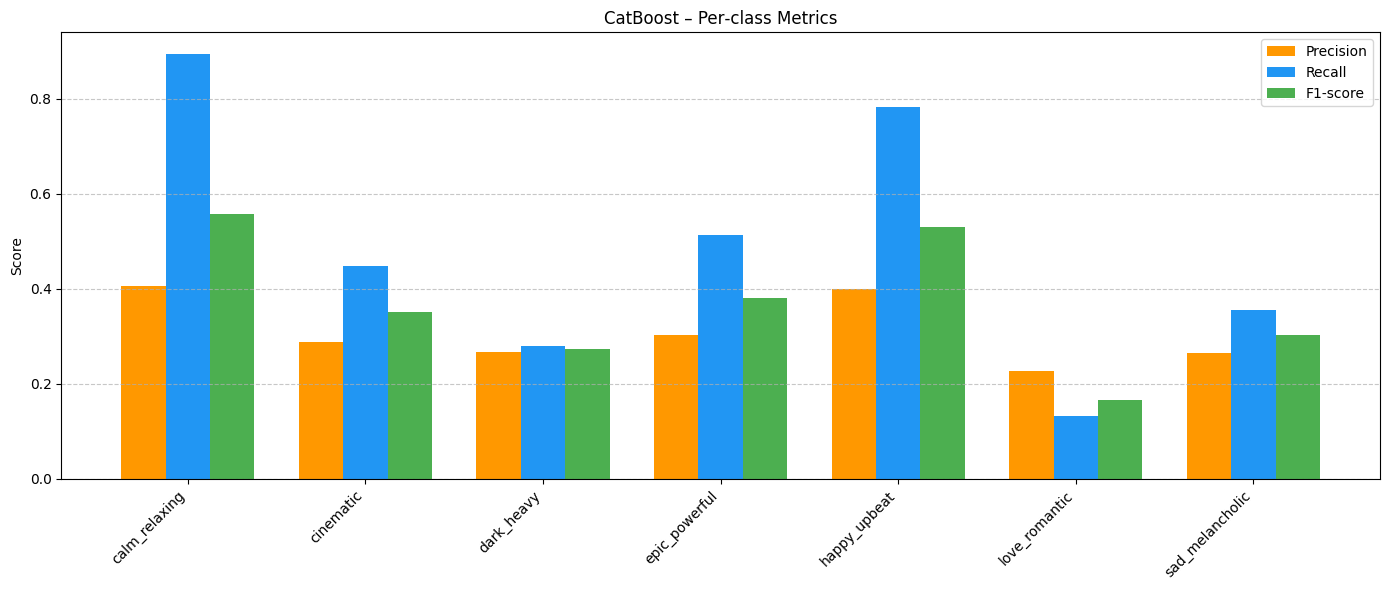

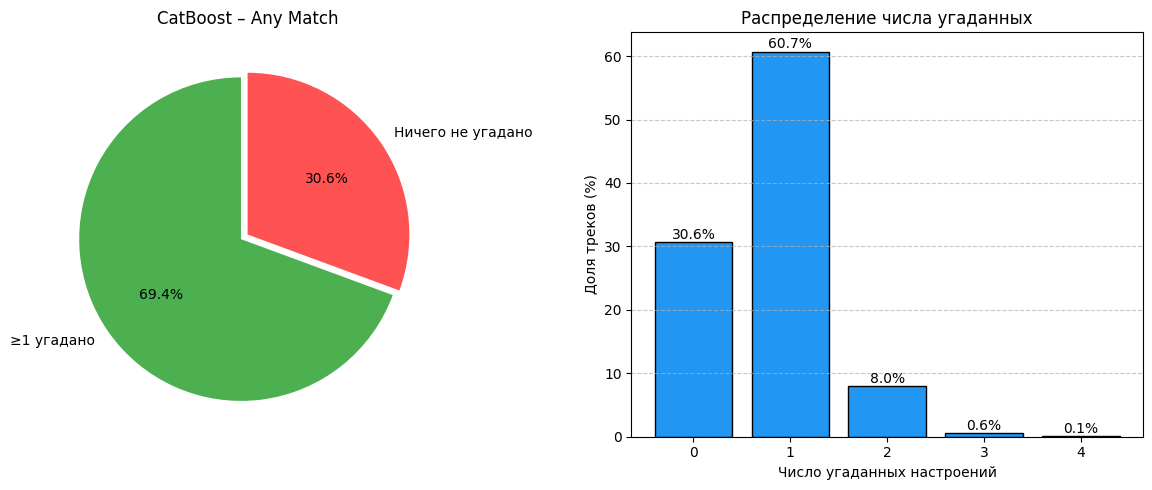

In [51]:
print(classification_report(y_test, test_preds_cb, target_names=ALL_GROUPS, zero_division=0))

report = classification_report(y_test, test_preds_cb, target_names=ALL_GROUPS, output_dict=True, zero_division=0)
metrics_per_class = {label: {k: report[label][k] for k in ('precision', 'recall', 'f1-score')}
                     for label in ALL_GROUPS if label in report}

x = np.arange(len(ALL_GROUPS))
width = 0.25
precisions = [metrics_per_class[g]['precision'] for g in ALL_GROUPS]
recalls    = [metrics_per_class[g]['recall'] for g in ALL_GROUPS]
f1s        = [metrics_per_class[g]['f1-score'] for g in ALL_GROUPS]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, precisions, width, label='Precision', color='#FF9800')
ax.bar(x,        recalls,    width, label='Recall',    color='#2196F3')
ax.bar(x + width, f1s,       width, label='F1-score',  color='#4CAF50')
ax.set_xticks(x)
ax.set_xticklabels(ALL_GROUPS, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('CatBoost – Per‑class Metrics')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'catboost_per_class_metrics.png'), dpi=150)
plt.show()

any_cb = ((y_test.astype(int) & test_preds_cb.astype(int)).sum(axis=1) > 0).mean()
exact_cb = (y_test.astype(int) == test_preds_cb.astype(int)).all(axis=1).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
labels_pie = ['≥1 угадано', 'Ничего не угадано']
sizes = [any_cb*100, 100-any_cb*100]
colors = ['#4CAF50', '#FF5252']
ax1.pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0))
ax1.set_title('CatBoost – Any Match')

hits = (y_test.astype(int) & test_preds_cb.astype(int)).sum(axis=1)
cnt = Counter(hits)
total = len(hits)
bars = ax2.bar([int(k) for k in sorted(cnt.keys())], [cnt[k]/total*100 for k in sorted(cnt.keys())],
               color='#2196F3', edgecolor='black')
ax2.set_xlabel('Число угаданных настроений')
ax2.set_ylabel('Доля треков (%)')
ax2.set_title('Распределение числа угаданных')
for bar, (k, _) in zip(bars, sorted(cnt.items())):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{cnt[k]/total*100:.1f}%', ha='center')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'catboost_metrics.png'), dpi=150)
plt.show()

catBoost с извлечением признаков

In [40]:
def extract_spotify_like_features(audio_path, sr=22050, duration=30):
    y, sr = librosa.load(audio_path, sr=sr, mono=True, duration=duration)
    features = {}
    
    # 1. Темп (BPM)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    features['tempo'] = float(tempo[0]) if hasattr(tempo, '__len__') else float(tempo)
    
    # 2. RMS (энергичность / громкость)
    rms = librosa.feature.rms(y=y)
    features['rms_mean'] = float(rms.mean())
    features['rms_std']  = float(rms.std())
    
    # 3. Спектральный центроид
    centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
    features['centroid_mean'] = float(centroid.mean())
    
    # 4. Спектральная ширина
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
    features['bandwidth_mean'] = float(bandwidth.mean())
    
    # 5. Спектральный спад (rolloff)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    features['rolloff_mean'] = float(rolloff.mean())
    
    # 6. Zero Crossing Rate
    zcr = librosa.feature.zero_crossing_rate(y)
    features['zcr_mean'] = float(zcr.mean())
    
    # 7. MFCC (первые 5 коэффициентов)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=5)
    for i in range(5):
        features[f'mfcc_{i+1}_mean'] = float(mfcc[i].mean())
    
    # 8. Chroma (тональность)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features['chroma_mean'] = float(chroma.mean())
    
    # 9. Harmonic ratio (акустичность)
    y_harm, y_perc = librosa.effects.hpss(y)
    harm_energy = np.sum(y_harm**2)
    perc_energy = np.sum(y_perc**2)
    features['harmonic_ratio'] = float(harm_energy / (harm_energy + perc_energy + 1e-10))
    
    return features

# Извлекаем для всех трёх выборок
train_feats = [extract_spotify_like_features(track_to_path[tid]) for tid in tqdm(train_ids_new, desc="Train features")]
val_feats   = [extract_spotify_like_features(track_to_path[tid]) for tid in tqdm(val_ids_new,   desc="Val features")]
test_feats  = [extract_spotify_like_features(track_to_path[tid]) for tid in tqdm(test_ids_new,  desc="Test features")]

# Преобразуем в DataFrame
train_df = pd.DataFrame(train_feats)
val_df   = pd.DataFrame(val_feats)
test_df  = pd.DataFrame(test_feats)

# Список признаков (все колонки, кроме track_id, если есть)
feature_cols = train_df.columns.tolist()
print(f"Извлечено признаков: {len(feature_cols)}")
print(train_df.head())

# Нормализация
scaler_spec = StandardScaler()
X_train_spec = scaler_spec.fit_transform(train_df[feature_cols])
X_val_spec   = scaler_spec.transform(val_df[feature_cols])
X_test_spec  = scaler_spec.transform(test_df[feature_cols])

Test features: 100%|███████████████████████████████████████████████████████████████| 1499/1499 [31:25<00:00,  1.26s/it]

Извлечено признаков: 14
        tempo  rms_mean   rms_std  centroid_mean  bandwidth_mean  \
0  117.453835  0.229560  0.053584    1621.073628     2084.972394   
1  129.199219  0.113758  0.061208    2453.595094     2447.559653   
2   92.285156  0.062702  0.020175     536.412896      905.502443   
3  129.199219  0.029845  0.017948    3211.355562     3125.685817   
4   99.384014  0.092053  0.044784    1367.833943     2015.822367   

   rolloff_mean  zcr_mean  mfcc_1_mean  mfcc_2_mean  mfcc_3_mean  mfcc_4_mean  \
0   3738.185729  0.046645  -131.765427   123.945869    29.203352    34.895390   
1   5128.052325  0.110310   -95.142532    83.214684   -21.337877    10.380141   
2    916.661124  0.022717  -405.685272   174.684631    41.691460    31.987461   
3   7168.848318  0.164180  -301.476959    59.190910    46.556164    37.317390   
4   2594.850976  0.053313  -230.405716   145.452896    29.741659    14.109115   

   mfcc_5_mean  chroma_mean  harmonic_ratio  
0    15.740692     0.389495       

In [42]:
from catboost import CatBoostClassifier
from sklearn.isotonic import IsotonicRegression

# Базовая модель CatBoost
cb_base = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function='MultiLogloss',
    verbose=100,
    random_seed=42,
    thread_count=-1
)

# One-vs-Rest
multi_cb = OneVsRestClassifier(cb_base)
multi_cb.fit(X_train_spec, y_train)

# Предсказания до калибровки
val_probs_raw = multi_cb.predict_proba(X_val_spec)
test_probs_raw = multi_cb.predict_proba(X_test_spec)

# Изотоническая калибровка для каждого настроения
calibrated_val = np.zeros_like(val_probs_raw)
calibrated_test = np.zeros_like(test_probs_raw)
iso_calibrators = []  

for c in range(len(ALL_GROUPS)):
    iso = IsotonicRegression(out_of_bounds='clip', y_min=0, y_max=1)
    iso.fit(val_probs_raw[:, c], y_val[:, c])
    calibrated_val[:, c] = iso.predict(val_probs_raw[:, c])
    calibrated_test[:, c] = iso.predict(test_probs_raw[:, c])
    iso_calibrators.append(iso)   # сохраняем обученный калибратор

# Поиск оптимального порога на валидации
best_t_cb, best_f1_cb = 0.5, 0.0
for t in np.arange(0.05, 0.95, 0.05):
    preds = (calibrated_val > t).astype(int)
    f1 = f1_score(y_val, preds, average='micro', zero_division=0)
    if f1 > best_f1_cb:
        best_f1_cb, best_t_cb = f1, t

# Предсказания на тесте
test_preds_cb_st = (calibrated_test > best_t_cb).astype(int)

print(f"CatBoost (статья): порог {best_t_cb:.2f}, micro‑F1 {best_f1_cb:.4f}")
print(classification_report(y_test, test_preds_cb_st, target_names=ALL_GROUPS, zero_division=0))

0:	learn: 0.6729326	total: 6.37ms	remaining: 1.9s
100:	learn: 0.5318809	total: 569ms	remaining: 1.12s
200:	learn: 0.4811492	total: 1.11s	remaining: 545ms
299:	learn: 0.4401128	total: 1.64s	remaining: 0us
0:	learn: 0.6351881	total: 5.52ms	remaining: 1.65s
100:	learn: 0.3780574	total: 532ms	remaining: 1.05s
200:	learn: 0.3322035	total: 1.06s	remaining: 520ms
299:	learn: 0.2951985	total: 1.57s	remaining: 0us
0:	learn: 0.6184731	total: 5.59ms	remaining: 1.67s
100:	learn: 0.3038974	total: 515ms	remaining: 1.01s
200:	learn: 0.2622370	total: 1.02s	remaining: 505ms
299:	learn: 0.2274596	total: 1.54s	remaining: 0us
0:	learn: 0.6442901	total: 5.98ms	remaining: 1.79s
100:	learn: 0.3999832	total: 497ms	remaining: 978ms
200:	learn: 0.3554342	total: 989ms	remaining: 487ms
299:	learn: 0.3183384	total: 1.47s	remaining: 0us
0:	learn: 0.6499433	total: 5.58ms	remaining: 1.67s
100:	learn: 0.4289608	total: 496ms	remaining: 978ms
200:	learn: 0.3795079	total: 990ms	remaining: 487ms
299:	learn: 0.3409462	tota

                 precision    recall  f1-score   support

  calm_relaxing       0.40      0.89      0.55       503
      cinematic       0.28      0.61      0.39       259
     dark_heavy       0.34      0.29      0.32       197
  epic_powerful       0.29      0.49      0.37       275
   happy_upbeat       0.47      0.76      0.58       396
  love_romantic       0.21      0.11      0.14       152
sad_melancholic       0.26      0.65      0.37       251

      micro avg       0.35      0.63      0.45      2033
      macro avg       0.32      0.54      0.39      2033
   weighted avg       0.35      0.63      0.43      2033
    samples avg       0.38      0.64      0.44      2033



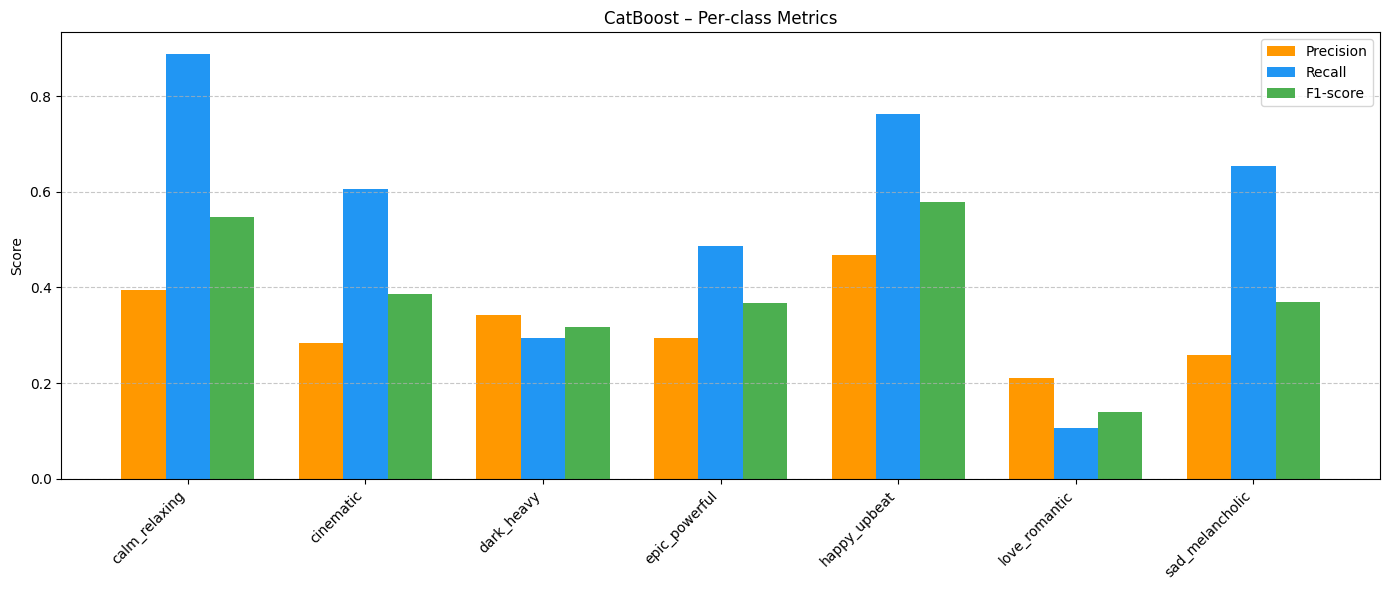

CatBoost – Any Match: 73.0%
CatBoost – Exact Match: 8.6%
CatBoost – Среднее число угаданных: 0.85 из 1.36


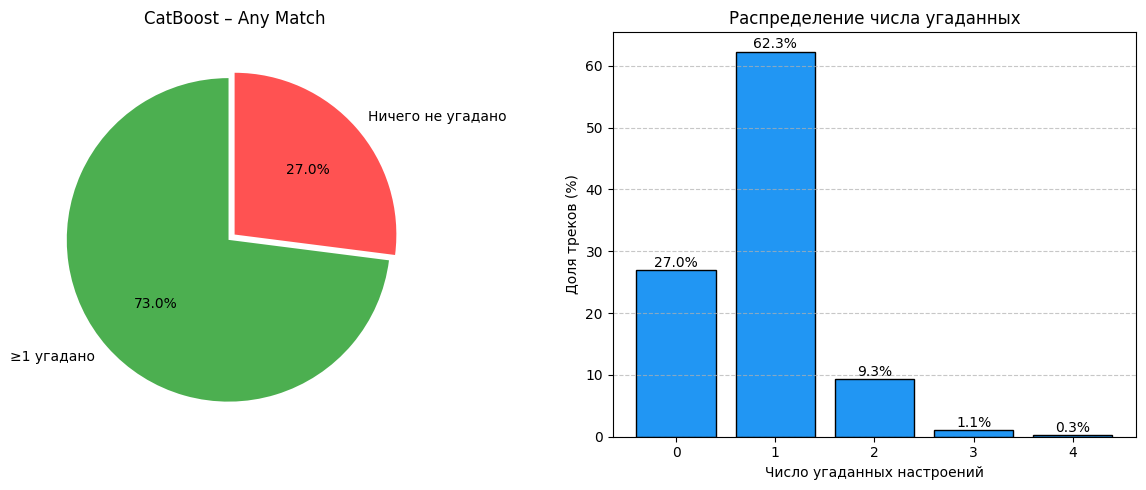

In [43]:
print(classification_report(y_test, test_preds_cb_st, target_names=ALL_GROUPS, zero_division=0))

report = classification_report(y_test, test_preds_cb_st, target_names=ALL_GROUPS, output_dict=True, zero_division=0)
metrics_per_class = {label: {k: report[label][k] for k in ('precision', 'recall', 'f1-score')}
                     for label in ALL_GROUPS if label in report}

x = np.arange(len(ALL_GROUPS))
width = 0.25
precisions = [metrics_per_class[g]['precision'] for g in ALL_GROUPS]
recalls    = [metrics_per_class[g]['recall'] for g in ALL_GROUPS]
f1s        = [metrics_per_class[g]['f1-score'] for g in ALL_GROUPS]

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, precisions, width, label='Precision', color='#FF9800')
ax.bar(x,        recalls,    width, label='Recall',    color='#2196F3')
ax.bar(x + width, f1s,       width, label='F1-score',  color='#4CAF50')
ax.set_xticks(x)
ax.set_xticklabels(ALL_GROUPS, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('CatBoost – Per‑class Metrics')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'catboost_per_class_metrics.png'), dpi=150)
plt.show()

def calc_any_match(y_true, y_pred):
    return ((y_true.astype(int) & y_pred.astype(int)).sum(axis=1) > 0).mean()

def calc_exact_match(y_true, y_pred):
    return (y_true.astype(int) == y_pred.astype(int)).all(axis=1).mean()

any_cb = calc_any_match(y_test, test_preds_cb_st)
exact_cb = calc_exact_match(y_test, test_preds_cb_st)
hits_cb = (y_test.astype(int) & test_preds_cb_st.astype(int)).sum(axis=1).mean()

print(f"CatBoost – Any Match: {any_cb*100:.1f}%")
print(f"CatBoost – Exact Match: {exact_cb*100:.1f}%")
print(f"CatBoost – Среднее число угаданных: {hits_cb:.2f} из {y_test.sum(axis=1).mean():.2f}")

# Визуализация human‑friendly метрик
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
labels_pie = ['≥1 угадано', 'Ничего не угадано']
sizes = [any_cb*100, 100-any_cb*100]
colors = ['#4CAF50', '#FF5252']
ax1.pie(sizes, labels=labels_pie, autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0))
ax1.set_title('CatBoost – Any Match')

hits = (y_test.astype(int) & test_preds_cb_st.astype(int)).sum(axis=1)
cnt = Counter(hits)
total = len(hits)
bars = ax2.bar([int(k) for k in sorted(cnt.keys())], [cnt[k]/total*100 for k in sorted(cnt.keys())],
               color='#2196F3', edgecolor='black')
ax2.set_xlabel('Число угаданных настроений')
ax2.set_ylabel('Доля треков (%)')
ax2.set_title('Распределение числа угаданных')
for bar, (k, _) in zip(bars, sorted(cnt.items())):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{cnt[k]/total*100:.1f}%', ha='center')
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'catboost_human_metrics.png'), dpi=150)
plt.show()


Финальная сводка моделей:
              Model  Micro-F1  Macro-F1  Any Match (%)  Exact Match (%)
Logistic Regression  0.424088  0.346365      61.307538        14.076051
             VGGish  0.494600  0.412629      67.978652        22.148099
         Simple CNN  0.432175  0.325832      63.842562        13.342228
           CatBoost  0.436115  0.365976      69.379586         9.939960
  CatBoost (статья)  0.448264  0.386592      72.981988         8.605737


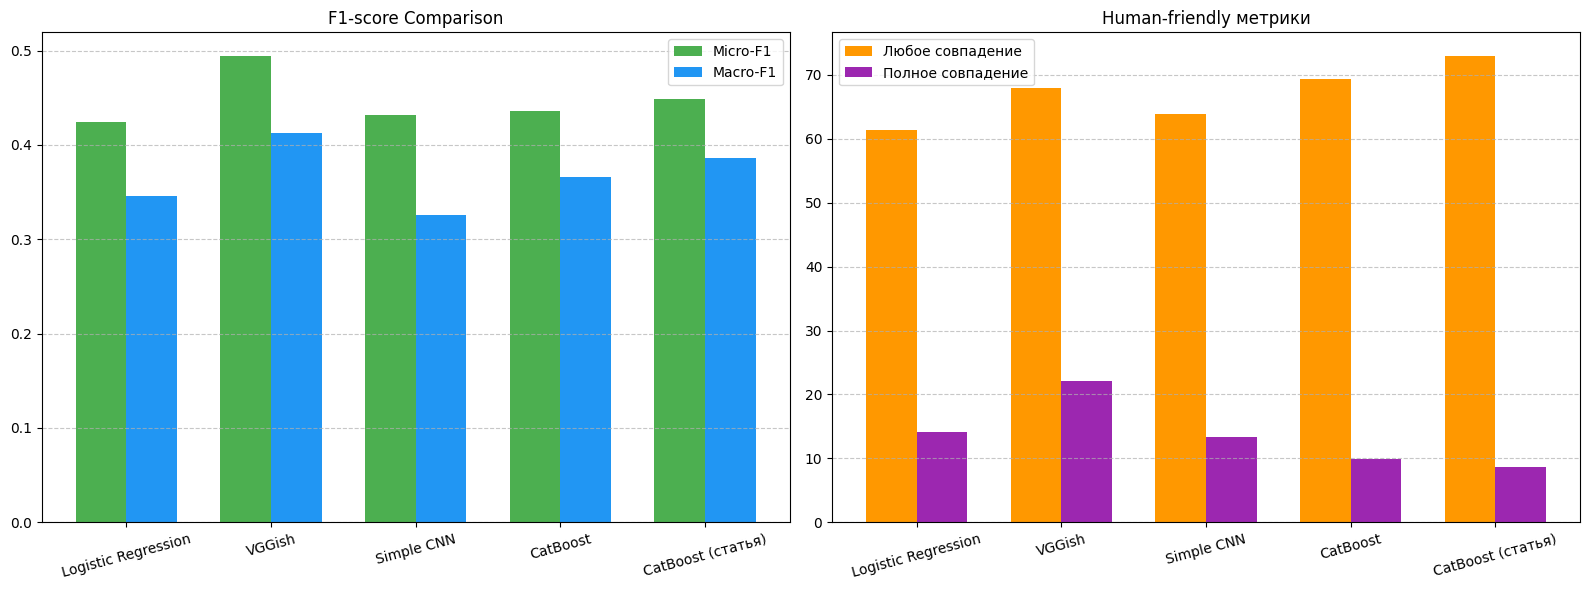

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from collections import Counter
import os

def calc_any_match(y_true, y_pred):
    """Доля треков, у которых хотя бы одно настроение угадано."""
    return ((y_true.astype(int) & y_pred.astype(int)).sum(axis=1) > 0).mean()

def calc_exact_match(y_true, y_pred):
    """Доля треков с полным совпадением всех меток."""
    return (y_true.astype(int) == y_pred.astype(int)).all(axis=1).mean()

def calc_avg_hits(y_true, y_pred):
    """Среднее число угаданных настроений на трек."""
    return (y_true.astype(int) & y_pred.astype(int)).sum(axis=1).mean()

all_models = []

# Логистическая регрессия
if 'test_preds_lr' in dir():
    micro_f1 = f1_score(y_test, test_preds_lr, average='micro', zero_division=0)
    macro_f1 = f1_score(y_test, test_preds_lr, average='macro', zero_division=0)
    any_match = calc_any_match(y_test, test_preds_lr)
    exact_match = calc_exact_match(y_test, test_preds_lr)
    all_models.append({
        'Model': 'Logistic Regression',
        'Micro-F1': micro_f1,
        'Macro-F1': macro_f1,
        'Any Match (%)': any_match*100,
        'Exact Match (%)': exact_match*100
    })

# VGGish
if 'test_preds_vgg' in dir():
    micro_f1 = f1_score(y_test, test_preds_vgg, average='micro', zero_division=0)
    macro_f1 = f1_score(y_test, test_preds_vgg, average='macro', zero_division=0)
    any_match = calc_any_match(y_test, test_preds_vgg)
    exact_match = calc_exact_match(y_test, test_preds_vgg)
    all_models.append({
        'Model': 'VGGish',
        'Micro-F1': micro_f1,
        'Macro-F1': macro_f1,
        'Any Match (%)': any_match*100,
        'Exact Match (%)': exact_match*100
    })

# Простая CNN
if 'test_preds_cnn' in dir():
    micro_f1 = f1_score(y_test, test_preds_cnn, average='micro', zero_division=0)
    macro_f1 = f1_score(y_test, test_preds_cnn, average='macro', zero_division=0)
    any_match = calc_any_match(y_test, test_preds_cnn)
    exact_match = calc_exact_match(y_test, test_preds_cnn)
    all_models.append({
        'Model': 'Simple CNN',
        'Micro-F1': micro_f1,
        'Macro-F1': macro_f1,
        'Any Match (%)': any_match*100,
        'Exact Match (%)': exact_match*100
    })

# CatBoost 
if 'test_preds_cb' in dir():
    micro_f1 = f1_score(y_test, test_preds_cb, average='micro', zero_division=0)
    macro_f1 = f1_score(y_test, test_preds_cb, average='macro', zero_division=0)
    any_match = calc_any_match(y_test, test_preds_cb)
    exact_match = calc_exact_match(y_test, test_preds_cb)
    all_models.append({
        'Model': 'CatBoost',
        'Micro-F1': micro_f1,
        'Macro-F1': macro_f1,
        'Any Match (%)': any_match*100,
        'Exact Match (%)': exact_match*100
    })

# CatBoost (статья)
if 'test_preds_cb_st' in dir():
    micro_f1 = f1_score(y_test, test_preds_cb_st, average='micro', zero_division=0)
    macro_f1 = f1_score(y_test, test_preds_cb_st, average='macro', zero_division=0)
    any_match = calc_any_match(y_test, test_preds_cb_st)
    exact_match = calc_exact_match(y_test, test_preds_cb_st)
    all_models.append({
        'Model': 'CatBoost (статья)',
        'Micro-F1': micro_f1,
        'Macro-F1': macro_f1,
        'Any Match (%)': any_match*100,
        'Exact Match (%)': exact_match*100
    })

df_res = pd.DataFrame(all_models)
print("Финальная сводка моделей:")
print(df_res.to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(df_res['Model']))
w = 0.35

# F1-score
ax[0].bar(x - w/2, df_res['Micro-F1'], w, label='Micro-F1', color='#4CAF50')
ax[0].bar(x + w/2, df_res['Macro-F1'], w, label='Macro-F1', color='#2196F3')
ax[0].set_xticks(x)
ax[0].set_xticklabels(df_res['Model'], rotation=15)
ax[0].set_title('F1‑score Comparison')
ax[0].legend()
ax[0].grid(axis='y', linestyle='--', alpha=0.7)

ax[1].bar(x - w/2, df_res['Any Match (%)'], w, label='Любое совпадение', color='#FF9800')
ax[1].bar(x + w/2, df_res['Exact Match (%)'], w, label='Полное совпадение', color='#9C27B0')
ax[1].set_xticks(x)
ax[1].set_xticklabels(df_res['Model'], rotation=15)
ax[1].set_title('Human‑friendly метрики')
ax[1].legend()
ax[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'all_models_comparison.png'), dpi=150)
plt.show()